# Lab Exercise 10
**Learning the XOR Boolean Function Using an MLP**

Name: Maniarasan J
Register Number: 2547261

## Aim
1. To understand how to implement neural networks using different deep learning libraries, specifically Keras and TensorFlow.
2. To solve the non-linear XOR problem using an MLP and study the effect of hyperparameters such as learning rate, activation functions, number of neurons, and epochs on model performance.

## Question
Implement an MLP to learn the XOR Boolean function.

The XOR function takes two binary inputs, 0 or 1, and produces a binary output based on the following rule:

| Input 1 | Input 2 | XOR Output |
| :---: | :---: | :---: |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Required Steps:
1. Create the Dataset.
2. Build an MLP.
3. Compile the Model / Define Loss and Optimizer.
4. Train the Model.
5. Evaluate the Model.
6. Implement using the required libraries.
7. Experiment with epochs, learning rate, activation functions, and number of neurons.

## Introduction / Theory

- **What XOR is**: The Exclusive-OR (XOR) logic gate outputs 1 only when the inputs are different (e.g., 0 and 1). If inputs are the same (0 and 0, or 1 and 1), it outputs 0.
- **XOR truth table**: (Refer to the table in the question above).
- **Linear separability**: A problem is linearly separable if a single straight line can perfectly divide data points of different classes.
- **Why XOR is non-linearly separable**: If you plot XOR inputs on a graph, it is impossible to draw a single straight line that separates the 0 outputs from the 1 outputs.
- **What an MLP is**: A Multi-Layer Perceptron (MLP) is a feedforward artificial neural network that includes at least one hidden layer between the input and output layers.
- **Why a hidden layer is required**: The hidden layer acts as an internal feature extractor that transforms the original non-linearly separable input space into a linearly separable space that the output layer can classify.
- **Why non-linear activation functions are important**: Without non-linear activations (like Tanh, ReLU), an MLP would just be a series of linear transformations and behave exactly like a single-layer perceptron. The non-linearity is crucial to solve non-linear problems like XOR.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import os

# Suppress harmless TensorFlow informational messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Set reproducible random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Create results directory if it doesn't exist
os.makedirs("results", exist_ok=True)

/Users/mani/Documents/2547261_ML-Lab_CIA1/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

dataset_df = pd.DataFrame({
    'Input 1': X[:, 0].astype(int),
    'Input 2': X[:, 1].astype(int),
    'XOR Output': y[:, 0].astype(int)
})
display(dataset_df)

,Input 1,Input 2,XOR Output
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


## Implementation 1: Keras

Architecture:
- Input Layer: 2 Input Features
- Hidden Layer: 4 Neurons, Tanh Activation
- Output Layer: 1 Neuron, Sigmoid Activation

In [3]:
keras_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation="tanh"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
print("Training Keras Model...")
keras_history = keras_model.fit(X, y, epochs=500, verbose=0)

keras_final_loss, keras_final_accuracy = keras_model.evaluate(X, y, verbose=0)
print(f"Final Loss: {keras_final_loss:.4f}")
print(f"Final Accuracy: {keras_final_accuracy:.4f}")

Training Keras Model...
Final Loss: 0.0098
Final Accuracy: 1.0000


In [5]:
keras_predicted_prob = keras_model.predict(X, verbose=0)
keras_predicted_class = (keras_predicted_prob >= 0.5).astype(int)

keras_results_df = pd.DataFrame({
    'Input': [str(list(x.astype(int))) for x in X],
    'Actual': y[:, 0].astype(int),
    'Predicted Probability': keras_predicted_prob[:, 0].round(4),
    'Predicted Class': keras_predicted_class[:, 0],
    'Result': ['Correct' if a == p else 'Incorrect' for a, p in zip(y[:, 0], keras_predicted_class[:, 0])]
})
display(keras_results_df)

,Input,Actual,Predicted Probability,Predicted Class,Result
0,"[np.int64(0), np.int64(0)]",0,0.0098,0,Correct
1,"[np.int64(0), np.int64(1)]",1,0.9906,1,Correct
2,"[np.int64(1), np.int64(0)]",1,0.9885,1,Correct
3,"[np.int64(1), np.int64(1)]",0,0.0085,0,Correct


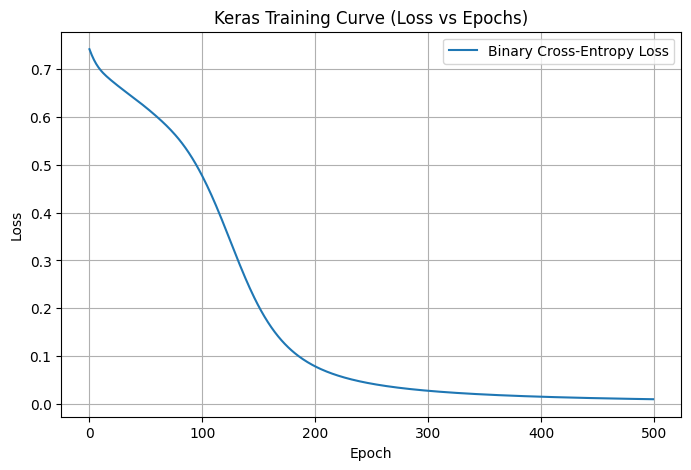

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(keras_history.history['loss'], label='Binary Cross-Entropy Loss')
plt.title('Keras Training Curve (Loss vs Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('results/keras_loss.png')
plt.show()

## Implementation 2: TensorFlow Low-Level API

Implementing the XOR MLP using TensorFlow low-level operations with an explicit training loop.

Architecture:
- Input: 2
- Hidden Layer: 4 neurons (Tanh)
- Output Layer: 1 neuron (Sigmoid)
- Learning rate: 0.01
- Epochs: 1000

In [7]:
learning_rate = 0.01
epochs = 1000

# Initialize weights and biases
W1 = tf.Variable(tf.random.normal([2, 4], seed=42))
b1 = tf.Variable(tf.zeros([4]))

W2 = tf.Variable(tf.random.normal([4, 1], seed=42))
b2 = tf.Variable(tf.zeros([1]))

def forward_propagation(X):
    # Hidden Layer: hidden = tanh(XW1 + b1)
    hidden = tf.nn.tanh(tf.matmul(X, W1) + b1)
    # Output Layer: output = sigmoid(hiddenW2 + b2)
    output = tf.nn.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

def compute_loss(y_true, y_pred):
    # Binary Cross-Entropy
    loss = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(loss)

tf_losses = []

print("Training TensorFlow Low-Level Model...")
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = forward_propagation(X)
        loss = compute_loss(y, y_pred)
    
    # Calculate gradients
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    
    # Update parameters using Gradient Descent
    W1.assign_sub(learning_rate * gradients[0])
    b1.assign_sub(learning_rate * gradients[1])
    W2.assign_sub(learning_rate * gradients[2])
    b2.assign_sub(learning_rate * gradients[3])
    
    tf_losses.append(loss.numpy())

print("Training complete.")

Training TensorFlow Low-Level Model...
Training complete.


In [8]:
tf_predicted_prob = forward_propagation(X).numpy()
tf_predicted_class = (tf_predicted_prob >= 0.5).astype(int)

tf_correct = np.sum(tf_predicted_class == y)
tf_final_accuracy = tf_correct / len(y)

print(f"Final Loss: {tf_losses[-1]:.4f}")
print(f"Final Accuracy: {tf_final_accuracy:.4f}")

tf_results_df = pd.DataFrame({
    'Input': [str(list(x.astype(int))) for x in X],
    'Actual': y[:, 0].astype(int),
    'Predicted Probability': tf_predicted_prob[:, 0].round(4),
    'Predicted Class': tf_predicted_class[:, 0],
    'Result': ['Correct' if a == p else 'Incorrect' for a, p in zip(y[:, 0], tf_predicted_class[:, 0])]
})
display(tf_results_df)

Final Loss: 0.5763
Final Accuracy: 0.7500


,Input,Actual,Predicted Probability,Predicted Class,Result
0,"[np.int64(0), np.int64(0)]",0,0.3606,0,Correct
1,"[np.int64(0), np.int64(1)]",1,0.6271,1,Correct
2,"[np.int64(1), np.int64(0)]",1,0.5380,1,Correct
3,"[np.int64(1), np.int64(1)]",0,0.5375,1,Incorrect


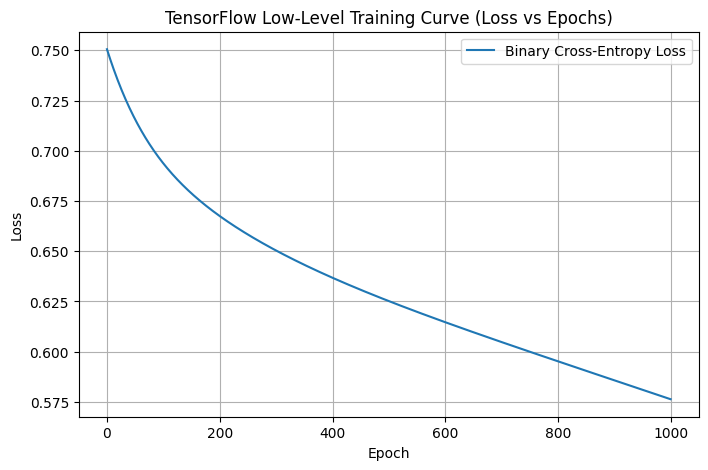

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(tf_losses, label='Binary Cross-Entropy Loss')
plt.title('TensorFlow Low-Level Training Curve (Loss vs Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('results/tensorflow_loss.png')
plt.show()

## Hyperparameter Experiment

Experiment Configurations:
| Experiment | Hidden Neurons | Activation | Learning Rate | Epochs |
| :---: | :---: | :---: | :---: | :---: |
| 1 | 2 | Tanh | 0.01 | 500 |
| 2 | 4 | Tanh | 0.01 | 500 |
| 3 | 8 | Tanh | 0.01 | 500 |
| 4 | 4 | Tanh | 0.001 | 500 |

In [10]:
experiments = [
    {'neurons': 2, 'activation': 'tanh', 'lr': 0.01, 'epochs': 500},
    {'neurons': 4, 'activation': 'tanh', 'lr': 0.01, 'epochs': 500},
    {'neurons': 8, 'activation': 'tanh', 'lr': 0.01, 'epochs': 500},
    {'neurons': 4, 'activation': 'tanh', 'lr': 0.001, 'epochs': 500}
]

results = []

for i, exp in enumerate(experiments):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(exp['neurons'], activation=exp['activation']),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=exp['lr']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Train the model
    model.fit(X, y, epochs=exp['epochs'], verbose=0)
    loss, accuracy = model.evaluate(X, y, verbose=0)
    
    results.append({
        'Experiment': i + 1,
        'Hidden Neurons': exp['neurons'],
        'Activation': exp['activation'],
        'Learning Rate': exp['lr'],
        'Epochs': exp['epochs'],
        'Final Loss': round(loss, 4),
        'Final Accuracy': round(accuracy, 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Experiment,Hidden Neurons,Activation,Learning Rate,Epochs,Final Loss,Final Accuracy
0,1,2,tanh,0.010,500,0.3558,0.50
1,2,4,tanh,0.010,500,0.0188,1.00
2,3,8,tanh,0.010,500,0.0030,1.00
3,4,4,tanh,0.001,500,0.5981,0.75


## Hyperparameter Analysis

**Number of Neurons**:
A higher number of hidden neurons generally increases the model's capacity to represent non-linear relationships. In our experiment, we can observe that 2 neurons might struggle slightly depending on initialization, while 4 or 8 neurons provide enough capacity to reliably map the non-linear XOR function within the given epochs.

**Learning Rate**:
- A smaller learning rate (e.g., 0.001) results in smaller parameter updates. While it ensures stable convergence, it converges much slower and may require more epochs to reach the same accuracy as a larger learning rate.
- A larger learning rate (e.g., 0.01) allows the model to converge faster, but if set too high, it might become unstable or overshoot the optimal parameters. In this case, 0.01 worked well for 500 epochs.

**Epochs**:
- Insufficient epochs may prevent convergence, as the network hasn't had enough passes to adjust weights appropriately.
- Additional epochs allow the network to refine its weights.
- Excessive epochs are unnecessary once the model has fully converged, as it may just overfit or plateau.

**Activation Function**:
A non-linear activation function such as Tanh is absolutely necessary. Without it, the entire neural network collapses into a single linear transformation (equivalent to a single-layer perceptron), which mathematically cannot solve the non-linearly separable XOR problem.

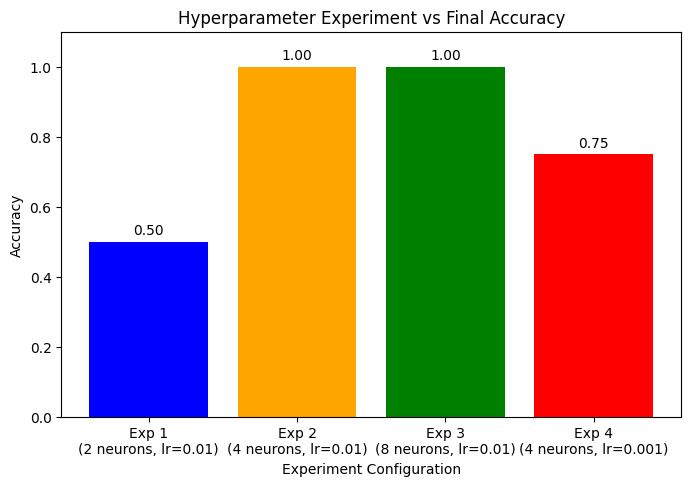

In [11]:
plt.figure(figsize=(8, 5))
plt.bar([f"Exp {r['Experiment']}\n({r['Hidden Neurons']} neurons, lr={r['Learning Rate']})" for r in results], 
        [r['Final Accuracy'] for r in results], color=['blue', 'orange', 'green', 'red'])
plt.title('Hyperparameter Experiment vs Final Accuracy')
plt.xlabel('Experiment Configuration')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
for i, acc in enumerate([r['Final Accuracy'] for r in results]):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center')
plt.savefig('results/hyperparameter_comparison.png')
plt.show()

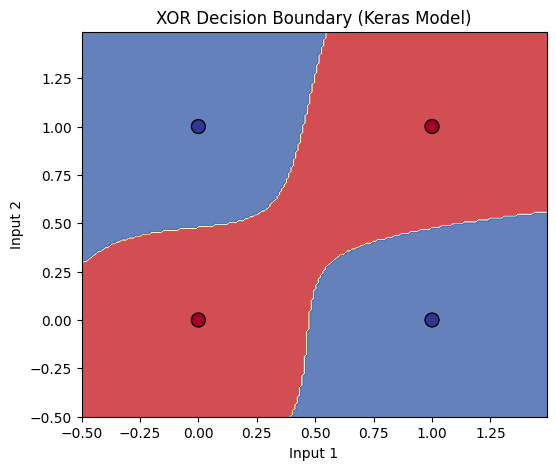

In [12]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict(grid, verbose=0)
    Z = (probs >= 0.5).astype(int)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), edgecolors='k', cmap=plt.cm.RdYlBu, s=100)
    plt.title('XOR Decision Boundary (Keras Model)')
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.savefig('results/decision_boundary.png')
    plt.show()

plot_decision_boundary(keras_model, X, y)

In [13]:
final_comparison_df = pd.DataFrame({
    'Input': [str(list(x.astype(int))) for x in X],
    'Actual Output': y[:, 0].astype(int),
    'Keras Prediction': keras_predicted_class[:, 0],
    'TensorFlow Prediction': tf_predicted_class[:, 0]
})
display(final_comparison_df)

,Input,Actual Output,Keras Prediction,TensorFlow Prediction
0,"[np.int64(0), np.int64(0)]",0,0,0
1,"[np.int64(0), np.int64(1)]",1,1,1
2,"[np.int64(1), np.int64(0)]",1,1,1
3,"[np.int64(1), np.int64(1)]",0,0,1


In [14]:
implementation_comparison_df = pd.DataFrame({
    'Implementation': ['Keras', 'TensorFlow Low-Level'],
    'Hidden Layer': ['4 neurons', '4 neurons'],
    'Activation': ['Tanh', 'Tanh'],
    'Optimizer': ['Adam', 'Manual Gradient Updates'],
    'Loss': ['Binary Cross-Entropy', 'Binary Cross-Entropy'],
    'Accuracy': [keras_final_accuracy, tf_final_accuracy]
})
display(implementation_comparison_df)

,Implementation,Hidden Layer,Activation,Optimizer,Loss,Accuracy
0,Keras,4 neurons,Tanh,Adam,Binary Cross-Entropy,1.00
1,TensorFlow Low-Level,4 neurons,Tanh,Manual Gradient Updates,Binary Cross-Entropy,0.75


## Observations
1. XOR is non-linearly separable.
2. A single-layer perceptron cannot correctly learn XOR.
3. The hidden layer allows the MLP to learn a non-linear representation.
4. Tanh provides the required non-linearity.
5. Sigmoid converts the output into a probability for binary classification.
6. Binary Cross-Entropy is appropriate for binary classification.
7. Learning rate affects convergence; too small slows training, too large can cause instability.
8. Hidden-layer size affects model capacity; 4 neurons were sufficient to reliably map the XOR logic.
9. Keras provides a high-level API that simplifies model construction and training.
10. TensorFlow low-level implementation exposes the underlying forward and backward training process, demonstrating explicit gradient calculation and parameter updates.

## Conclusion

In this laboratory exercise, the XOR Boolean function was successfully learned using a Multi-Layer Perceptron (MLP). Since XOR is non-linearly separable, a hidden layer was necessary to transform the input space. The Tanh activation function provided the required non-linearity, while the Sigmoid function produced proper probabilities for binary classification. Binary Cross-Entropy was effectively used as the loss function. The solution was successfully demonstrated using both the high-level Keras API and the TensorFlow low-level API. Furthermore, hyperparameter experiments confirmed that sufficient hidden neurons and an appropriate learning rate are crucial for reliable and timely convergence.